In [1]:
### Getting the data from the internet

import requests
import pandas as pd

# Define the endpoint URL
url = "https://custom.resbank.co.za/SarbWebApi/SarbData/IFData/GetInstitutionData/BA900/2025-01-01/TOTAL"

# Set headers to mimic a browser
headers = {
    "Accept": "application/json, text/javascript, */*; q=0.01",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",
    "Origin": "https://www.resbank.co.za",
    "Referer": "https://www.resbank.co.za/",
    "Connection": "keep-alive"
}

# Send GET request
response = requests.get(url, headers=headers)

# Check success
if response.status_code == 200:
    print("✅ Successfully fetched BA900 TOTAL data.")

    # Parse JSON
    data_json = response.json()

    # Convert to DataFrame
    df = pd.DataFrame(data_json)

    # Save to CSV
    df.to_csv("BA900_TOTAL_2025-01-01.csv", index=False)
    print("💾 CSV file saved: BA900_TOTAL_2025-01-01.csv")

    # Optional preview
    print(df.head())
else:
    print(f"❌ Failed to fetch data. Status code: {response.status_code}")


✅ Successfully fetched BA900 TOTAL data.
💾 CSV file saved: BA900_TOTAL_2025-01-01.csv
  IFType InstitutionId InstitutionName      Period  LastUpdate  \
0  BA900         TOTAL         *TOTAL*  2025-01-01  2025-04-11   

                                             XMLData  
0  <SARBForms xmlns:xsi="http://www.w3.org/2001/X...  


In [2]:
df.head()

,IFType,InstitutionId,InstitutionName,Period,LastUpdate,XMLData
0,BA900,TOTAL,*TOTAL*,2025-01-01,2025-04-11,"<SARBForms xmlns:xsi=""http://www.w3.org/2001/X..."


In [3]:
file_path = './BA900_TOTAL_2025-01-01.csv'

tenth_column_data = []

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()[1:]  # Skip the first line (header)
    for line in lines:
        
        columns = line.strip().split(',')
        data = columns[5].replace('\"\"', '"').replace('\"<','<').replace('\">','>')
        

In [4]:
data

'<SARBForms xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns:xsd="http://www.w3.org/2001/XMLSchema" Type="BA900" Description="BA900 Forms" TheYear="2025" TheMonth="01" TheDay="31" InstitutionCode="TOTAL" InstitutionDescription="*TOTAL*" LastModified="20250131>  <SARBForm>    <Table TableNumber="1" TableDescription="LIABILITIES AT MONTH-END>      <ColumnHeader ColumnNumber="1" ColumnCode="1" ColumnDescription="Chequej" />      <ColumnHeader ColumnNumber="2" ColumnCode="2" ColumnDescription="Savings" />      <ColumnHeader ColumnNumber="3" ColumnCode="3" ColumnDescription="Up to 1 day" />      <ColumnHeader ColumnNumber="4" ColumnCode="4" ColumnDescription="More than 1 day to 1 month" />      <ColumnHeader ColumnNumber="5" ColumnCode="5" ColumnDescription="More than 1 month to 6 months" />      <ColumnHeader ColumnNumber="6" ColumnCode="6" ColumnDescription="More than 6 months" />      <ColumnHeader ColumnNumber="7" ColumnCode="7" ColumnDescription="TOTAL" />      <ColumnHeader

In [5]:
import xml.etree.ElementTree as ET
import pandas as pd

# Step 2: Prepare for parsing
all_rows = []
column_names = []

# Step 3: Loop through XML and parse it
for xml_str in data:
    try:
        root = ET.fromstring(xml_str)

        # Each SARBForm in SARBForms
        for sarb_form in root.findall(".//SARBForm"):
            for table in sarb_form.findall("Table"):

                # Extract headers (once)
                if not column_names:
                    headers = table.findall("ColumnHeader")
                    column_names = [col.attrib.get("ColumnDescription", "") for col in headers]

                # Extract rows
                for row in table.findall("Row"):
                    item_number = row.attrib.get("ItemNumber")
                    item_desc = row.attrib.get("ItemDescription")
                    values = [col.attrib.get("Value") for col in row.findall("Column")]
                    all_rows.append([item_number, item_desc] + values)

    except ET.ParseError as e:
        print("Skipping malformed XML:", e)

# Step 4: Build DataFrame
if all_rows:
    column_headers = ["Item Number", "Description"] + column_names
    df = pd.DataFrame(all_rows, columns=column_headers)
    df.iloc[:, 2:] = df.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")
    print(df.head())
else:
    print("No rows were parsed from the XML.")


Skipping malformed XML: unclosed token: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: no element found: line 1, column 1
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skipping malformed XML: syntax error: line 1, column 0
Skip

In [6]:
df.head()

,IFType,InstitutionId,InstitutionName,Period,LastUpdate,XMLData
0,BA900,TOTAL,*TOTAL*,2025-01-01,2025-04-11,"<SARBForms xmlns:xsi=""http://www.w3.org/2001/X..."


In [7]:
# Extract the last column
last_column_df = df[[df.columns[-1]]]

In [8]:
last_column_df

,XMLData
0,"<SARBForms xmlns:xsi=""http://www.w3.org/2001/X..."


In [9]:
import xml.etree.ElementTree as ET
import pandas as pd

# Get the XML string from the first row of the last column
xml_string = last_column_df.iloc[0, 0]  # First row, only column

# Parse the XML
root = ET.fromstring(xml_string)

# Output containers
all_rows = []
column_names = []

# Loop through <SARBForm> elements
for sarb_form in root.findall(".//SARBForm"):
    for table in sarb_form.findall("Table"):

        # Capture column headers (only once)
        if not column_names:
            headers = table.findall("ColumnHeader")
            column_names = [col.attrib.get("ColumnDescription", "") for col in headers]

        # Extract rows
        for row in table.findall("Row"):
            item_number = row.attrib.get("ItemNumber")
            item_desc = row.attrib.get("ItemDescription")
            values = [col.attrib.get("Value") for col in row.findall("Column")]
            all_rows.append([item_number, item_desc] + values)

# Assemble final DataFrame
column_headers = ["Item Number", "Description"] + column_names
df_parsed = pd.DataFrame(all_rows, columns=column_headers)

# Convert numeric columns
df_parsed.iloc[:, 2:] = df_parsed.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")

# Preview
df_parsed.head()


,Item Number,Description,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,TOTAL,NCDs/PNs i (included in col. 7)
0,1,DEPOSITS (total of items 2 and 32),1288121307.9387,542081765.2382,1658054849.502,656246956.3666,851514385.0601,1107158452.0447,6103177716.1602,628135129.8923
1,2,DEPOSITS DENOMINATED IN RAND (total of items 3...,1223229379.5335,540712773.2382,1525373369.2173,601704431.1506,781570922.8921,1053071490.505,5725662365.5467,628135129.8923
2,3,SA banksb (total of items 4 and 5),6135273.3098,87438.5142,35709635.7576,7018227.5292,12258468.7327,34506049.9843,95715092.8177,14630478.0968
3,4,NCDs/PNsi,NaN,NaN,0.0,979368.0,3187381.9883,10463727.1085,14630477.0968,14630478.0968
4,5,Other deposits,6135273.3098,87438.5142,35709635.7576,6038859.5292,9071086.7444,24042322.8758,81084615.7209,NaN


In [10]:
import pandas as pd

In [11]:
# ### Importing data from CSV file as the webscraping is not working at this moment

# df = pd.read_csv("./TOTAL_2025-01-01.csv", skiprows=6)

In [12]:
df_parsed.head()

,Item Number,Description,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,TOTAL,NCDs/PNs i (included in col. 7)
0,1,DEPOSITS (total of items 2 and 32),1288121307.9387,542081765.2382,1658054849.502,656246956.3666,851514385.0601,1107158452.0447,6103177716.1602,628135129.8923
1,2,DEPOSITS DENOMINATED IN RAND (total of items 3...,1223229379.5335,540712773.2382,1525373369.2173,601704431.1506,781570922.8921,1053071490.505,5725662365.5467,628135129.8923
2,3,SA banksb (total of items 4 and 5),6135273.3098,87438.5142,35709635.7576,7018227.5292,12258468.7327,34506049.9843,95715092.8177,14630478.0968
3,4,NCDs/PNsi,NaN,NaN,0.0,979368.0,3187381.9883,10463727.1085,14630477.0968,14630478.0968
4,5,Other deposits,6135273.3098,87438.5142,35709635.7576,6038859.5292,9071086.7444,24042322.8758,81084615.7209,NaN


In [13]:
df_parsed.shape

(337, 10)

In [14]:
df_parsed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Item Number                       337 non-null    object
 1   Description                       337 non-null    object
 2   Chequej                           325 non-null    object
 3   Savings                           314 non-null    object
 4   Up to 1 day                       271 non-null    object
 5   More than 1 day to 1 month        265 non-null    object
 6   More than 1 month to 6 months     298 non-null    object
 7   More than 6 months                225 non-null    object
 8   TOTAL                             40 non-null     object
 9   NCDs/PNs i  (included in col. 7)  39 non-null     object
dtypes: object(10)
memory usage: 26.5+ KB


In [15]:
# Step 1: Convert all financial columns to numeric (force errors to NaN)
financial_columns = df_parsed.columns[2:]  # all columns except 'Description' and 'Item Number'

# Apply conversion
df_parsed[financial_columns] = df_parsed[financial_columns].apply(pd.to_numeric, errors='coerce')

# Step 2: Drop rows where all financial columns are NaN
df_cleaned = df_parsed.dropna(subset=financial_columns, how='all').copy()

# Step 3: Fill missing descriptions or item numbers if needed
df_cleaned['Description'] = df_cleaned['Description'].fillna(method='ffill')
df_cleaned['Item Number'] = df_cleaned['Item Number'].fillna(method='ffill')


C:\Users\andre\AppData\Local\Temp\ipykernel_36152\1272318095.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned['Description'] = df_cleaned['Description'].fillna(method='ffill')
C:\Users\andre\AppData\Local\Temp\ipykernel_36152\1272318095.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned['Item Number'] = df_cleaned['Item Number'].fillna(method='ffill')


In [16]:
# Preview cleaned data
df_cleaned.head(20)

,Item Number,Description,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,TOTAL,NCDs/PNs i (included in col. 7)
0,1,DEPOSITS (total of items 2 and 32),1.288121e+09,5.420818e+08,1.658055e+09,6.562470e+08,8.515144e+08,1.107158e+09,6.103178e+09,6.281351e+08
1,2,DEPOSITS DENOMINATED IN RAND (total of items 3...,1.223229e+09,5.407128e+08,1.525373e+09,6.017044e+08,7.815709e+08,1.053071e+09,5.725662e+09,6.281351e+08
2,3,SA banksb (total of items 4 and 5),6.135273e+06,8.743851e+04,3.570964e+07,7.018228e+06,1.225847e+07,3.450605e+07,9.571509e+07,1.463048e+07
3,4,NCDs/PNsi,NaN,NaN,0.000000e+00,9.793680e+05,3.187382e+06,1.046373e+07,1.463048e+07,1.463048e+07
4,5,Other deposits,6.135273e+06,8.743851e+04,3.570964e+07,6.038860e+06,9.071087e+06,2.404232e+07,8.108462e+07,NaN
5,6,Central and provincial government sector depos...,1.185018e+08,3.873154e+06,9.482221e+07,2.687096e+07,3.738198e+07,3.049154e+07,3.119417e+08,6.363487e+06
6,7,Central government of the Republic (total of i...,1.066709e+08,3.069751e+06,8.984161e+07,1.853807e+07,2.233971e+07,2.396496e+07,2.644250e+08,5.759865e+06
7,8,Tax and loan account,6.819361e+07,0.000000e+00,3.341347e+07,8.166000e+03,1.147100e+04,6.406000e+03,1.016331e+08,0.000000e+00
8,9,Other,3.847733e+07,3.069751e+06,5.642814e+07,1.852990e+07,2.232824e+07,2.395856e+07,1.627919e+08,5.759865e+06
9,10,Provincial governments,1.065060e+07,7.709062e+05,4.225972e+06,7.017028e+06,1.155092e+07,3.784598e+06,3.800002e+07,6.036230e+05


In [17]:
df_cleaned.to_excel("./BA900_TOTAL_2025-01-01_cleaned.xlsx")

In [18]:
# Drop irrelevant columns
df = df_cleaned.copy()

# Check for rows that likely contain NPL ratios based on 'Description' column
npl_df = df[df["Description"].str.contains("non-performing loans", case=False, na=False)]

# Also get deposit-related rows to estimate market share and lending activity
deposit_df = df[df["Description"].str.contains("deposit", case=False, na=False)]

# Combine both for overview
npl_summary = {
    "npl_rows": npl_df[["Item Number", "Description", "TOTAL"]],
    "deposit_rows": deposit_df[["Item Number", "Description", "TOTAL"]],
    "n_npl_rows": len(npl_df),
    "n_deposit_rows": len(deposit_df)
}

npl_summary


{'npl_rows': Empty DataFrame
 Columns: [Item Number, Description, TOTAL]
 Index: [],
 'deposit_rows':     Item Number                                        Description  \
 0             1                 DEPOSITS (total of items 2 and 32)   
 1             2  DEPOSITS DENOMINATED IN RAND (total of items 3...   
 4             5                                     Other deposits   
 5             6  Central and provincial government sector depos...   
 31           32  DEPOSITS DENOMINATED IN FOREIGN CURRENCY (tota...   
 42           43       SA Reserve Bank and Corporation for Publi...   
 58           59    SA Reserve Bank and Corporation for Public D...   
 105         106  Domestic currency deposits with SA Reserve Ban...   
 107         108         Cash reserve deposits: Noninterest bearing   
 108         109                                     Other deposits   
 109         110  DEPOSITS, LOANS AND ADVANCES (total of items 1...   
 115         116   Other deposits with and loan

In [19]:
# Extract only relevant rows for deposit-based market share estimation
deposit_rows = df[df["Description"].str.contains("deposit", case=False, na=False)]

# Group by Description and sum to simulate bank deposit growth focus
deposit_summary = (
    deposit_rows.groupby("Description")["TOTAL"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Estimate market share: each deposit type as a percent of total deposits
total_deposits = deposit_summary["TOTAL"].sum()
deposit_summary["Market Share (%)"] = (deposit_summary["TOTAL"] / total_deposits) * 100

# Identify long-term lending behavior: deposits with longer maturity
long_term_keywords = ["6 months", "foreign", "nonfinancial", "public", "advances"]
deposit_summary["Lending Focus Category"] = deposit_summary["Description"].apply(
    lambda x: "Long-Term/Risky" if any(k in x.lower() for k in long_term_keywords) else "Stable/Core"
)

deposit_summary.head(10)


,Description,TOTAL,Market Share (%),Lending Focus Category
0,DEPOSITS (total of items 2 and 32),6.103178e+09,48.440295,Stable/Core
1,DEPOSITS DENOMINATED IN RAND (total of items 3...,5.725662e+09,45.443995,Stable/Core
2,DEPOSITS DENOMINATED IN FOREIGN CURRENCY (tota...,3.775153e+08,2.996301,Long-Term/Risky
3,Central and provincial government sector depos...,3.119417e+08,2.475849,Stable/Core
4,Other deposits,8.108462e+07,0.643560,Stable/Core
5,SA Reserve Bank and Corporation for Publi...,0.000000e+00,0.000000,Long-Term/Risky
6,Cash reserve deposits: Noninterest bearing,0.000000e+00,0.000000,Stable/Core
7,Deposits with and advances to SA Reserve Bank,0.000000e+00,0.000000,Long-Term/Risky
8,Deposits with and advances to SA banksd,0.000000e+00,0.000000,Long-Term/Risky
9,Deposits with and advances to foreign banks,0.000000e+00,0.000000,Long-Term/Risky


In [23]:
import plotly.express as px

# Filter out deposit types with 0% market share
filtered_deposit_summary = deposit_summary[deposit_summary["Market Share (%)"] > 0]

# Recreate Pie Chart (no 0% values)
fig_pie_filtered = px.pie(
    filtered_deposit_summary,
    names="Description",
    values="Market Share (%)",
    title="Simulated Market Share by Deposit Type (Excluding 0%)"
)

fig_pie_filtered.show()


In [21]:
import requests

url = "https://www.resbank.co.za/en/home/what-we-do/statistics/key-statistics"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36"}

response = requests.get(url, headers=headers)

print("Content-Type:", response.headers.get("Content-Type"))
print("First 500 characters of response:")
print(response.text[:500])


Content-Type: text/html;charset=utf-8
First 500 characters of response:

<!DOCTYPE HTML>
<html lang="en">
    <head>
<script type="text/javascript">
(function(){
window["loaderConfig"] = "/TSPD/?type=21";
})();

</script>

<script type="text/javascript" src="/TSPD/?type=18"></script>

    <meta charset="UTF-8"/>
    <title>Key Statistics</title>
    <meta name="keywords" content="Standard Tags"/>
    <meta name="description" content="Key Statistics"/>
    <meta name="template" content="sarb-internet-site-content-page-template"/>
    <meta name="viewport" co


In [22]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

# Setup headless Chrome
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")

# Launch browser
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# Load SARB Key Statistics page
url = "https://www.resbank.co.za/en/home/what-we-do/statistics/key-statistics"
driver.get(url)
time.sleep(5)  # wait for JavaScript to load the table

# Grab the rendered HTML
html = driver.page_source
driver.quit()

# Parse the page
soup = BeautifulSoup(html, "html.parser")

# Find the specific table by class name
table = soup.find("table", class_="table otherindicatorstable")

# Extract rows
data = []
for row in table.find_all("tr"):
    cols = row.find_all(["td", "th"])
    row_data = [col.get_text(strip=True) for col in cols]
    data.append(row_data)

# Convert to DataFrame
df_macro = pd.DataFrame(data[1:], columns=data[0])

# Show result
print("\n📊 Extracted 'Other Indicators' Table:\n")
print(df_macro.head())



📊 Extracted 'Other Indicators' Table:

                                           Indicator Value Last Period  \
0                                   Other Indicators                     
1                               Real GDP growth rate   2.3   Dec, 2024   
2                           Gross saving as % of GDP  12.8   Dec, 2024   
3                           Foreign Debt as % of GDP  41.5        2023   
4  National government balance as % of GDP (Fisca...  -4.4   Dec, 2024   

  Movement  
0        i  
1           
2           
3           
4           


In [24]:
# Convert to DataFrame and drop first row and last three rows
df_macro_cleaned = df_macro.iloc[1:-3, :-1].reset_index(drop=True)

In [25]:
df_macro_cleaned

,Indicator,Value,Last Period
0,Real GDP growth rate,2.3,"Dec, 2024"
1,Gross saving as % of GDP,12.8,"Dec, 2024"
2,Foreign Debt as % of GDP,41.5,2023
3,National government balance as % of GDP (Fisca...,-4.4,"Dec, 2024"
4,"Current account balance (R millions, seasonall...",-31632,"Dec, 2024"
5,M3,6.05,"Feb, 2025"
6,Claims on the domestic private sector,3.68,"Feb, 2025"
7,Import cover (months),5.6,"Dec, 2024"


In [26]:
# Convert to wide format for merging with BA900 data (assume all for Q1 2025)
macro_snapshot_extended = df_macro_cleaned.set_index("Indicator")["Value"].to_dict()
macro_snapshot_extended["Quarter"] = "2025Q1"

In [27]:
macro_snapshot_extended

{'Real GDP growth rate': '2.3',
 'Gross saving as % of GDP': '12.8',
 'Foreign Debt as % of GDP': '41.5',
 'National government balance as % of GDP (Fiscal year)': '-4.4',
 'Current account balance (R millions, seasonally adjusted at annual rate)': '-31632',
 'M3': '6.05',
 'Claims on the domestic private sector': '3.68',
 'Import cover (months)': '5.6',
 'Quarter': '2025Q1'}

In [28]:
# Convert to displayable format
df_macro_extended_snapshot = pd.DataFrame([macro_snapshot_extended])

In [29]:
df_macro_extended_snapshot

,Real GDP growth rate,Gross saving as % of GDP,Foreign Debt as % of GDP,National government balance as % of GDP (Fiscal year),"Current account balance (R millions, seasonally adjusted at annual rate)",M3,Claims on the domestic private sector,Import cover (months),Quarter
0,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,2025Q1


In [30]:
df_cleaned.head()

,Item Number,Description,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,TOTAL,NCDs/PNs i (included in col. 7)
0,1,DEPOSITS (total of items 2 and 32),1.288121e+09,5.420818e+08,1.658055e+09,6.562470e+08,8.515144e+08,1.107158e+09,6.103178e+09,6.281351e+08
1,2,DEPOSITS DENOMINATED IN RAND (total of items 3...,1.223229e+09,5.407128e+08,1.525373e+09,6.017044e+08,7.815709e+08,1.053071e+09,5.725662e+09,6.281351e+08
2,3,SA banksb (total of items 4 and 5),6.135273e+06,8.743851e+04,3.570964e+07,7.018228e+06,1.225847e+07,3.450605e+07,9.571509e+07,1.463048e+07
3,4,NCDs/PNsi,NaN,NaN,0.000000e+00,9.793680e+05,3.187382e+06,1.046373e+07,1.463048e+07,1.463048e+07
4,5,Other deposits,6.135273e+06,8.743851e+04,3.570964e+07,6.038860e+06,9.071087e+06,2.404232e+07,8.108462e+07,NaN


In [31]:
df_cleaned.shape

(331, 10)

In [32]:
df_cleaned["Quarter"] = "2025Q1"

In [33]:
# Join macro snapshot to each BA900 row
df_joined = pd.merge(df_cleaned, df_macro_extended_snapshot, on="Quarter", how="left")

In [34]:
df_joined.head()

,Item Number,Description,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,TOTAL,NCDs/PNs i (included in col. 7),Quarter,Real GDP growth rate,Gross saving as % of GDP,Foreign Debt as % of GDP,National government balance as % of GDP (Fiscal year),"Current account balance (R millions, seasonally adjusted at annual rate)",M3,Claims on the domestic private sector,Import cover (months)
0,1,DEPOSITS (total of items 2 and 32),1.288121e+09,5.420818e+08,1.658055e+09,6.562470e+08,8.515144e+08,1.107158e+09,6.103178e+09,6.281351e+08,2025Q1,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6
1,2,DEPOSITS DENOMINATED IN RAND (total of items 3...,1.223229e+09,5.407128e+08,1.525373e+09,6.017044e+08,7.815709e+08,1.053071e+09,5.725662e+09,6.281351e+08,2025Q1,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6
2,3,SA banksb (total of items 4 and 5),6.135273e+06,8.743851e+04,3.570964e+07,7.018228e+06,1.225847e+07,3.450605e+07,9.571509e+07,1.463048e+07,2025Q1,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6
3,4,NCDs/PNsi,NaN,NaN,0.000000e+00,9.793680e+05,3.187382e+06,1.046373e+07,1.463048e+07,1.463048e+07,2025Q1,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6
4,5,Other deposits,6.135273e+06,8.743851e+04,3.570964e+07,6.038860e+06,9.071087e+06,2.404232e+07,8.108462e+07,NaN,2025Q1,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6


In [35]:
df_joined.shape

(331, 19)

In [36]:
df_joined.isnull().sum()

Item Number                                                                   0
Description                                                                   0
Chequej                                                                       6
Savings                                                                      17
Up to 1 day                                                                  60
More than 1 day to 1 month                                                   66
More than 1 month to 6 months                                                33
More than 6 months                                                          106
TOTAL                                                                       291
NCDs/PNs i  (included in col. 7)                                            292
Quarter                                                                       0
Real GDP growth rate                                                          0
Gross saving as % of GDP                

In [ ]:
# Quick and dirty fill for NaN values

df_joined.fillna(0, inplace=True)

In [38]:
df_joined.isnull().sum()

Item Number                                                                 0
Description                                                                 0
Chequej                                                                     0
Savings                                                                     0
Up to 1 day                                                                 0
More than 1 day to 1 month                                                  0
More than 1 month to 6 months                                               0
More than 6 months                                                          0
TOTAL                                                                       0
NCDs/PNs i  (included in col. 7)                                            0
Quarter                                                                     0
Real GDP growth rate                                                        0
Gross saving as % of GDP                                        

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Select features related to macro and deposit behavior
features = [
    "Chequej", "Savings", "Up to 1 day", "More than 1 day to 1 month",
    "More than 1 month to 6 months", "More than 6 months",
    "Real GDP growth rate", "Gross saving as % of GDP", "Foreign Debt as % of GDP",
    "National government balance as % of GDP (Fiscal year)",
    "Current account balance (R millions, seasonally adjusted at annual rate)", "M3",
    "Claims on the domestic private sector", "Import cover (months)"
]

target = "TOTAL"

# Prepare the data
df_model = df_joined[features + [target]].dropna()
X = df_model[features]
y = df_joined[target]

# Split into train and test for validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

r2, rmse, coef_df


(-66.60351358805302,
 353586551.2697496,
                                               Feature   Coefficient
 1                                             Savings  3.806579e+00
 5                                  More than 6 months  2.175475e+00
 2                                         Up to 1 day  1.105643e+00
 3                          More than 1 day to 1 month -7.905195e-01
 0                                             Chequej -2.662565e-01
 4                       More than 1 month to 6 months  5.031675e-02
 7                            Gross saving as % of GDP -1.010844e-36
 11                                                 M3 -9.292228e-37
 9   National government balance as % of GDP (Fisca...  5.054221e-37
 13                              Import cover (months)  4.833405e-37
 6                                Real GDP growth rate  2.527111e-37
 12              Claims on the domestic private sector -2.322613e-37
 8                            Foreign Debt as % of GDP  0.0000

In [40]:
# Store model summary
model_summary = {
    "coefficients": model.coef_,
    "intercept": model.intercept_,
    "mse": rmse,
    "r2": r2,
    "features": X.columns.tolist()
}

model_summary_df = pd.DataFrame({
    "Feature": model_summary["features"],
    "Coefficient": model_summary["coefficients"]
})

In [41]:
# Export this to use in the Streamlit app
df_cleaned.to_csv("./cleaned_features_new.csv", index=False)
model_summary_df.to_csv("./model_summary_new.csv", index=False)

C:\Users\andre\AppData\Local\Temp\ipykernel_36152\143222464.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




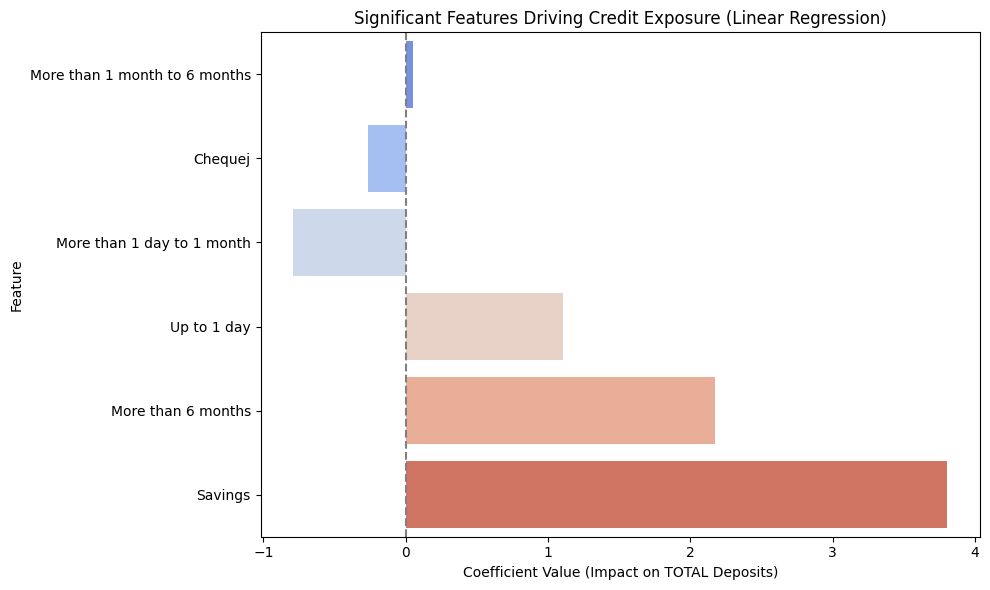

In [42]:
import seaborn as sns  
import matplotlib.pyplot as plt 

# Dynamically filter features with a meaningful impact (non-zero or significant magnitude)
impact_threshold = 1e-6  # To ignore coefficients that are effectively zero
filtered_features = coef_df[coef_df["Coefficient"].abs() > impact_threshold].copy()

# Sort by absolute coefficient value
filtered_features["abs_coef"] = filtered_features["Coefficient"].abs()
filtered_features = filtered_features.sort_values(by="abs_coef", ascending=True)

# Plot only impactful features
plt.figure(figsize=(10, 6))
sns.barplot(data=filtered_features, x="Coefficient", y="Feature", palette="coolwarm", orient="h")
plt.title("Significant Features Driving Credit Exposure (Linear Regression)")
plt.xlabel("Coefficient Value (Impact on TOTAL Deposits)")
plt.ylabel("Feature")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


In [43]:
# Add predictions from the linear regression model to the test set
df_results = X_test.copy()
df_results["Actual TOTAL"] = y_test
df_results["Predicted TOTAL"] = y_pred

In [44]:
# Add maturity categories
def categorize_maturity(row):
    short = row["Up to 1 day"]
    med = row["More than 1 day to 1 month"] + row["More than 1 month to 6 months"]
    long = row["More than 6 months"]
    if long > short + med:
        return "Long-Term Heavy"
    elif short > med + long:
        return "Short-Term Heavy"
    elif med > short + long:
        return "Mid-Term Heavy"
    else:
        return "Balanced"

df_results["Maturity Category"] = df_results.apply(categorize_maturity, axis=1)

In [45]:
df_results.head()

,Chequej,Savings,Up to 1 day,More than 1 day to 1 month,More than 1 month to 6 months,More than 6 months,Real GDP growth rate,Gross saving as % of GDP,Foreign Debt as % of GDP,National government balance as % of GDP (Fiscal year),"Current account balance (R millions, seasonally adjusted at annual rate)",M3,Claims on the domestic private sector,Import cover (months),Actual TOTAL,Predicted TOTAL,Maturity Category
25,5.235947e+07,9.942547e+06,3.977859e+07,8.227085e+06,6.623637e+06,2.671142e+06,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,1.196025e+08,5.597702e+07,Short-Term Heavy
307,5.054026e+07,0.000000e+00,2.444116e+07,0.000000e+00,0.000000e+00,2.609909e+07,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,0.000000e+00,5.879388e+07,Long-Term Heavy
73,3.390279e+05,0.000000e+00,7.869349e+05,1.125963e+06,0.000000e+00,0.000000e+00,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,0.000000e+00,-1.166086e+07,Mid-Term Heavy
219,2.154281e+06,0.000000e+00,0.000000e+00,0.000000e+00,2.154281e+06,0.000000e+00,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,0.000000e+00,-1.201576e+07,Mid-Term Heavy
57,6.651716e+07,2.545382e+07,7.515932e+07,1.671303e+08,1.671303e+08,0.000000e+00,2.3,12.8,41.5,-4.4,-31632,6.05,3.68,5.6,0.000000e+00,2.701987e+07,Mid-Term Heavy


In [46]:
df_results.to_csv('./results.csv')